In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset.csv


In [ ]:
data1 = pd.read_csv("ML-CaseStudy3-Dataset.csv")
data1.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [ ]:
print("Dataset Shape:")
print(data1.shape)

print("\nColumn Names:")
print(data1.columns)

print("\nDataset Information:")
print(data1.info())

print("\nStatistical Summary:")
print(data1.describe())

print("\nMissing Values:")
print(data1.isnull().sum())

Dataset Shape:
(2000, 19)

Column Names:
Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                2000 non-null   object 
 1   country                2000 non-null   object 
 2   region                 2000 non-null   object 
 3   report_date            2000 non-null   object 
 4   virus_strain           2000 non-null   object 
 5   transmission_type      2000 non-null   object 
 6   exposure_source        2000 non-n

In [ ]:
numerical_columns = data1.select_dtypes(include=np.number).columns

for col in numerical_columns:
    data1[col] = data1[col].fillna(data1[col].mean())

categorical_columns = data1.select_dtypes(include='object').columns

for col in categorical_columns:
    data1[col] = data1[col].fillna(data1[col].mode()[0])

print(data1.isnull().sum())

case_id                  0
country                  0
region                   0
report_date              0
virus_strain             0
transmission_type        0
exposure_source          0
patient_age              0
gender                   0
symptoms                 0
hospitalization          0
fatality                 0
recovery_days            0
temperature_celsius      0
humidity_percent         0
rodent_presence_index    0
quarantine_days          0
population_density       0
air_quality_index        0
dtype: int64


In [ ]:
data1.drop_duplicates(inplace=True)

In [ ]:
label_encoder = LabelEncoder()

data1['gender'] = label_encoder.fit_transform(data1['gender'])

data1['patient_age'] = label_encoder.fit_transform(data1['patient_age'])

data1.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,14,1,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,29,0,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,27,0,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,37,1,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,47,1,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


Objective:

The objective of this experiment is to implement
Ridge Regression algorithm to predict the
air quality index based on various health and
environmental factors such as patient age,
recovery days, temperature, humidity,
rodent presence index, and quarantine days.

Ridge Regression applies L2 regularization to
improve regression performance, reduce overfitting,
and handle multicollinearity in the dataset.

In [ ]:
X = data1.drop('exposure_source', axis=1)
y = data1['exposure_source']

print("Independent Variables:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Independent Variables:
        case_id    country          region report_date virus_strain  \
0  HV2026_00001     Canada  Lake Rickyside  24-11-2025   Sin Nombre   
1  HV2026_00002    Bolivia    East Crystal  22-04-2025   Sin Nombre   
2  HV2026_00003      Chile       Rossmouth  21-03-2025        Seoul   
3  HV2026_00004  Argentina       West Ryan  10-02-2025   Sin Nombre   
4  HV2026_00005      Chile       Mariaberg  25-03-2025      Dobrava   

  transmission_type  patient_age  gender                     symptoms  \
0   Rodent-to-Human           14       1    Headache, Vomiting, Fever   
1    Human-to-Human           29       0  Fever, Muscle Pain, Fatigue   
2    Human-to-Human           27       0  Fever, Muscle Pain, Fatigue   
3    Human-to-Human           37       1  Fever, Muscle Pain, Fatigue   
4   Rodent-to-Human           47       1       Fever, Cough, Headache   

  hospitalization fatality  recovery_days  temperature_celsius  \
0             Yes       No           22.0    

In [ ]:
print(data1.dtypes)
print(data1.select_dtypes(include='object').columns)

case_id                   object
country                   object
region                    object
report_date               object
virus_strain              object
transmission_type         object
exposure_source           object
patient_age                int64
gender                     int64
symptoms                  object
hospitalization           object
fatality                  object
recovery_days            float64
temperature_celsius      float64
humidity_percent         float64
rodent_presence_index      int64
quarantine_days            int64
population_density         int64
air_quality_index          int64
dtype: object
Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'symptoms', 'hospitalization',
       'fatality'],
      dtype='object')


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(1600, 18)
Testing Data Shape:
(400, 18)


In [ ]:
print(X_train.columns.tolist())


['case_id', 'country', 'region', 'report_date', 'virus_strain', 'transmission_type', 'patient_age', 'gender', 'symptoms', 'hospitalization', 'fatality', 'recovery_days', 'temperature_celsius', 'humidity_percent', 'rodent_presence_index', 'quarantine_days', 'population_density', 'air_quality_index']


In [ ]:
X = data1[['patient_age', 'recovery_days', 'temperature_celsius',
           'humidity_percent', 'rodent_presence_index', 'quarantine_days']]
y = data1['air_quality_index']

In [ ]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scaling

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print("Done!")

Done!


Text(0.5, 1.0, 'Actual vs. Predicted Values')

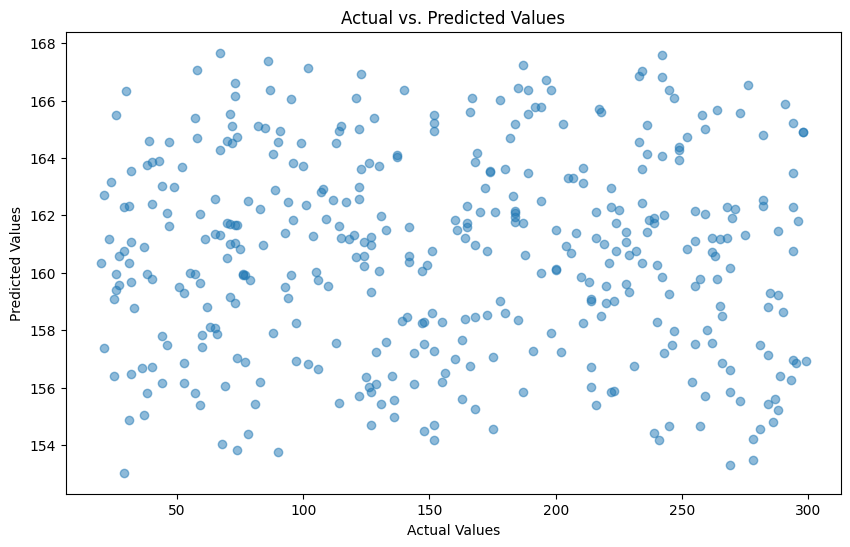

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")

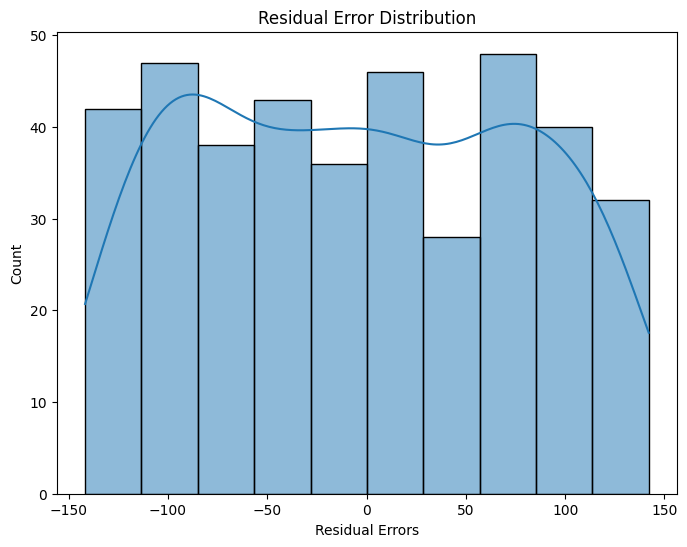

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Error Distribution")
plt.xlabel("Residual Errors")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': y_pred
})


print(comparison.head(20))

    Actual_Value  Predicted_Value
0            200       160.117717
1            206       160.675918
2            245       166.359443
3            156       156.513427
4            245       159.252605
5            278       154.202920
6            266       158.482431
7            255       162.167493
8            223       159.023550
9            252       160.814441
10            30       166.322660
11           214       159.026269
12           152       164.952845
13           142       160.581065
14           194       162.487634
15            20       160.334549
16           290       158.631150
17           234       167.033222
18            46       157.472232
19           144       156.106052


Conclusion:

In this analysis, Ridge Regression was applied to predict
air quality index using patient_age, recovery_days,
temperature_celsius, humidity_percent, rodent_presence_index,
and quarantine_days as independent variables.
Ridge Regression uses L2 regularization which helps to
reduce overfitting and handle multicollinearity in the data.
The model was trained on 80% data and tested on 20% data.
The R2 Score shows how well the model predicts air quality index.
MSE shows the average error in predictions.
Thus, Ridge Regression is an effective algorithm for
regression problems where overfitting needs to be controlled.